# AutoEIT — Transcription Quality: AssemblyAI (Universal-2) vs. whisper/parakeet/wav2vec2 (resegmented, hit recordings)

[AssemblyAI](https://www.assemblyai.com/) is the ASR backend the production autoeit.org platform
actually runs on (not Whisper/Replicate — those were only used for the RMAL research paper before
the platform was automated). It had never been benchmarked in this harness until now — every other
comparison here is an open-source alternative measured against human raters, so the advisor's
qualitative preference for AssemblyAI over Whisper (no hallucination/cleanup issues, but never
checked against our own WER/MER/CER numbers) was still unconfirmed.

Run via `src/transcription/transcribe_resegmented_assemblyai.py` using the `assemblyai` Python SDK,
pinned to the **Universal-2** speech model (`speech_models=["universal-2"]`) rather than whatever
AssemblyAI's API defaults to (currently `universal-3-5-pro`) — per advisor instruction, since the
goal is to evaluate the model actually running in production, not the newest release. `disfluencies=True`
is set so filler words aren't stripped before scoring, consistent with the advisor's separate note
that LLM-cleanup-style ASR postprocessing removes exactly the signal (fillers, false starts, repairs)
this research needs. Restricted to the 102 "hit" recordings in `data/resegmented_hit_recordings.txt`
— unlike whisper/parakeet/wav2vec2, which were also run on misses — since this is a billed API call
per item.

Merged with the existing whisper/parakeet/wav2vec2 outputs and the human-rater transcriptions via
`src/postprocessing/build_postprocessed_csv_resegmented.py` (same rank-based item&lt;-&gt;Sentence
alignment and WER/MER/CER scoring as the other resegmented-transcription-quality notebooks). A plain
4-column (stimuli / rater1 / rater2 / assemblyai) reviewable transcript sheet is written separately by
`src/postprocessing/build_assemblyai_excel.py` to `data/postprocessed/assemblyai_transcriptions.xlsx`.

## Metrics: WER, MER, and CER

- **WER (Word Error Rate)** = (S + D + I) / N, where N is the number of words in the reference.
  Unbounded above 1.0 when there are many insertions relative to the reference.
- **MER (Match Error Rate)** = (S + D + I) / (S + D + C + I). Same edit counts as WER, but always in
  [0, 1] — doesn't blow up the way WER can on insertion-heavy output.
- **CER (Character Error Rate)** — the same idea as WER but over characters, more forgiving of
  near-miss spelling/inflection errors and less sensitive to tokenization.

All three are computed after lowercasing and stripping punctuation, against each human rater
separately.


## Config

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path


In [2]:
POSTPROCESSED_ROOT = Path("../../data/postprocessed/resegmented")
VERSIONS = ["version_a", "version_b"]
ASR_SOURCES = ["whisper", "parakeet", "wav2vec2", "assemblyai"]
RATERS = ["rater1", "rater2"]
METRICS = ["wer", "mer", "cer"]

hit_recordings = set(Path("../../data/resegmented_hit_recordings.txt").read_text(encoding="utf-8").split())
print(f"{len(hit_recordings)} hit recordings")


102 hit recordings


## Load per-item scores

One tidy row per (recording, sentence, ASR source, rater), across all hit recordings.

In [3]:
def load_scores(recording_names: set[str]) -> pd.DataFrame:
    records = []
    for version in VERSIONS:
        version_dir = POSTPROCESSED_ROOT / version
        for recording_dir in sorted(version_dir.iterdir()):
            if recording_dir.name not in recording_names:
                continue
            df = pd.read_csv(recording_dir / "transcriptions.csv")
            for source in ASR_SOURCES:
                for rater in RATERS:
                    cols = [f"{source}_{m}_{rater}" for m in METRICS]
                    if cols[0] not in df.columns:
                        continue
                    sub = df[["sentence_number", *cols]].dropna()
                    for _, row in sub.iterrows():
                        records.append({
                            "version": version,
                            "recording": recording_dir.name,
                            "sentence_number": row["sentence_number"],
                            "source": source,
                            "rater": rater,
                            "wer": row[cols[0]],
                            "mer": row[cols[1]],
                            "cer": row[cols[2]],
                        })
    return pd.DataFrame(records)


scores = load_scores(hit_recordings)
n_rec = scores["recording"].nunique()
print(f"{len(scores)} scored items, {n_rec} recordings")


23516 scored items, 98 recordings


## Human floor

For context, the inter-rater agreement floor (rater1 vs. rater2, same scoring, see
`analyze_interrater_agreement.ipynb` for the full writeup) over this same 102-recording set, shown
alongside the ASR systems below.

In [4]:
def load_human_scores(recording_names: set[str]) -> pd.DataFrame:
    records = []
    for version in VERSIONS:
        version_dir = POSTPROCESSED_ROOT / version
        for recording_dir in sorted(version_dir.iterdir()):
            if recording_dir.name not in recording_names:
                continue
            df = pd.read_csv(recording_dir / "transcriptions.csv")
            if "human_wer" not in df.columns:
                continue
            sub = df[["sentence_number", "human_wer", "human_mer", "human_cer"]].dropna()
            for _, row in sub.iterrows():
                records.append({
                    "version": version,
                    "recording": recording_dir.name,
                    "sentence_number": row["sentence_number"],
                    "source": "human",
                    "rater": "rater1_vs_rater2",
                    "wer": row["human_wer"],
                    "mer": row["human_mer"],
                    "cer": row["human_cer"],
                })
    return pd.DataFrame(records)


human_scores = load_human_scores(hit_recordings)
scores_with_human = pd.concat([scores, human_scores], ignore_index=True)
print(f"human floor: {len(human_scores)} scored sentences")


human floor: 2940 scored sentences


In [5]:
source_colors = {
    "whisper": "#4C72B0",
    "parakeet": "#DD8452",
    "wav2vec2": "#55A868",
    "assemblyai": "#64B5CD",
    "human": "#777777",
}
DISPLAY_SOURCES = ASR_SOURCES + ["human"]


def summarize(scores: pd.DataFrame, order: list[str] = ASR_SOURCES) -> pd.DataFrame:
    mean_tbl = scores.groupby("source")[METRICS].mean().round(4).reindex(order)
    median_tbl = scores.groupby("source")[METRICS].median().round(4).reindex(order)
    pct_perfect = scores.groupby("source")["wer"].apply(lambda x: (x == 0).mean()).round(3).reindex(order)
    out = mean_tbl.add_suffix("_mean").join(median_tbl.add_suffix("_median"))
    out["wer_pct_perfect"] = pct_perfect
    return out


def plot_metrics(scores: pd.DataFrame, title: str, save_path: str, order: list[str] = ASR_SOURCES) -> None:
    summary = scores.groupby("source")[METRICS].mean().reindex(order)
    x = np.arange(len(order))
    width = 0.25

    fig, ax = plt.subplots(figsize=(10, 5))
    for i, metric in enumerate(METRICS):
        offset = (i - 1) * width
        bars = ax.bar(x + offset, summary[metric], width, label=metric.upper())
        for b in bars:
            h = b.get_height()
            ax.text(b.get_x() + b.get_width() / 2, h, f"{h:.3f}", ha="center", va="bottom", fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(order)
    ax.set_ylabel("Mean error rate")
    ax.set_title(title)
    ax.legend()
    fig.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()


## Hit recordings (n=102, both raters), all 4 ASR systems vs. human floor

In [6]:
summarize(scores_with_human, order=DISPLAY_SOURCES)

,wer_mean,mer_mean,cer_mean,wer_median,mer_median,cer_median,wer_pct_perfect
source,,,,,,,
whisper,0.2480,0.2166,0.1398,0.1429,0.1429,0.0476,0.349
parakeet,0.2805,0.2596,0.1558,0.1429,0.1429,0.0513,0.329
wav2vec2,0.3230,0.3003,0.1489,0.2500,0.2500,0.0769,0.207
assemblyai,0.2902,0.2787,0.1875,0.1429,0.1429,0.0536,0.350
human,0.1608,0.1501,0.0763,0.1111,0.1111,0.0250,0.429


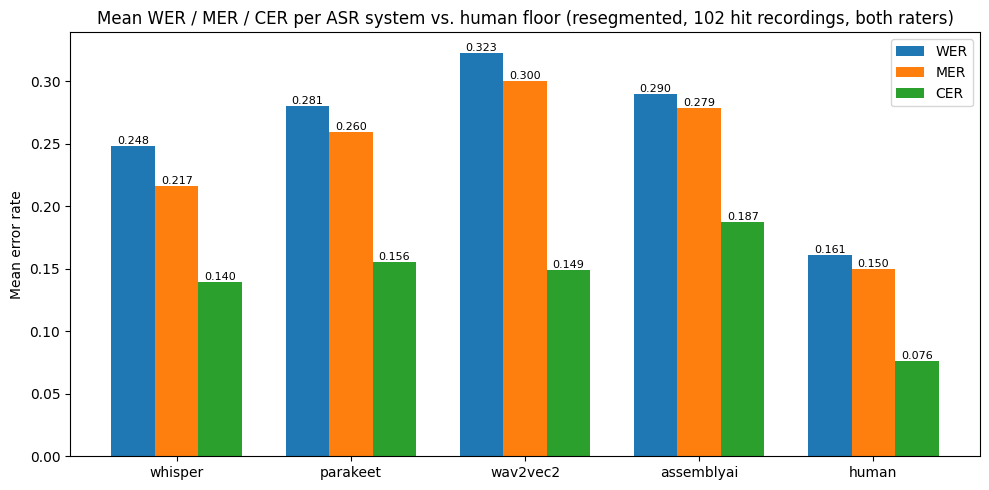

In [7]:
plot_metrics(
    scores_with_human,
    "Mean WER / MER / CER per ASR system vs. human floor (resegmented, 102 hit recordings, both raters)",
    "../plots/assemblyai_transcription_quality_metrics.png",
    order=DISPLAY_SOURCES,
)


## AssemblyAI vs. the previous best (whisper) only

Isolating the head-to-head comparison that motivated this test: does the actual production backend
(AssemblyAI, Universal-2) score better than our best open-source alternative (whisper large-v3) on
these hit recordings, or does the advisor's qualitative preference (no hallucination/cleanup issues)
not translate into a measured accuracy win against these raters?

In [8]:
summarize(scores, order=["whisper", "assemblyai"])

,wer_mean,mer_mean,cer_mean,wer_median,mer_median,cer_median,wer_pct_perfect
source,,,,,,,
whisper,0.2480,0.2166,0.1398,0.1429,0.1429,0.0476,0.349
assemblyai,0.2902,0.2787,0.1875,0.1429,0.1429,0.0536,0.350


## Each ASR system vs. human floor, individually

The combined chart above puts all four systems side by side, which makes the absolute gap to the
human floor hard to read once there are this many bars. One plot per system, isolating it against
just the human floor, for a cleaner one-on-one comparison.

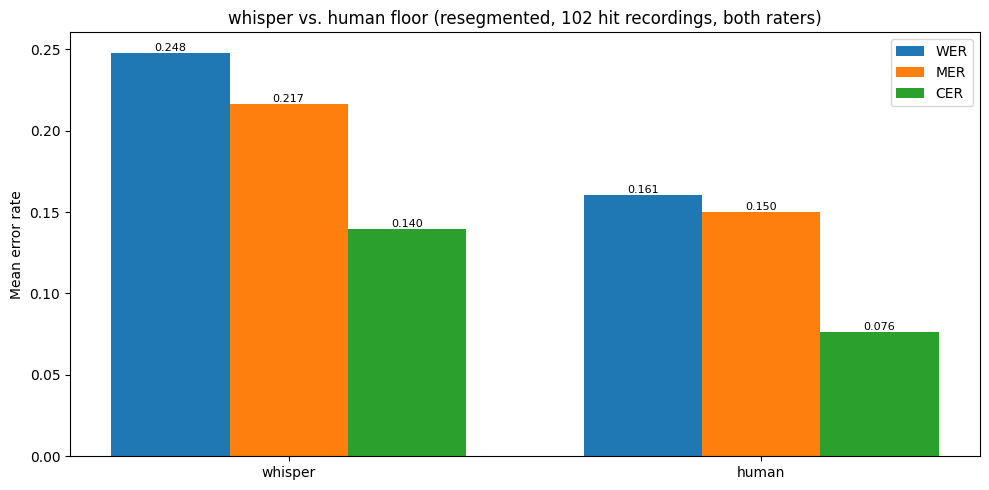

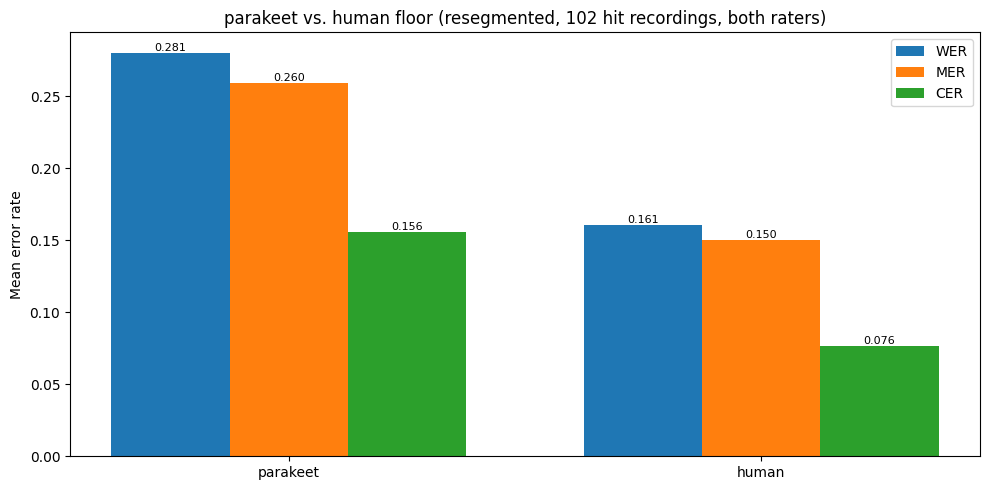

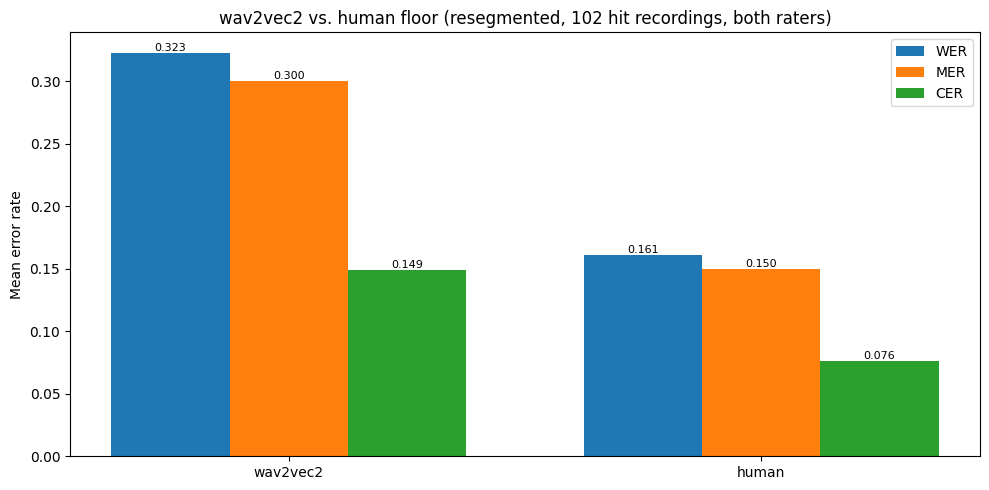

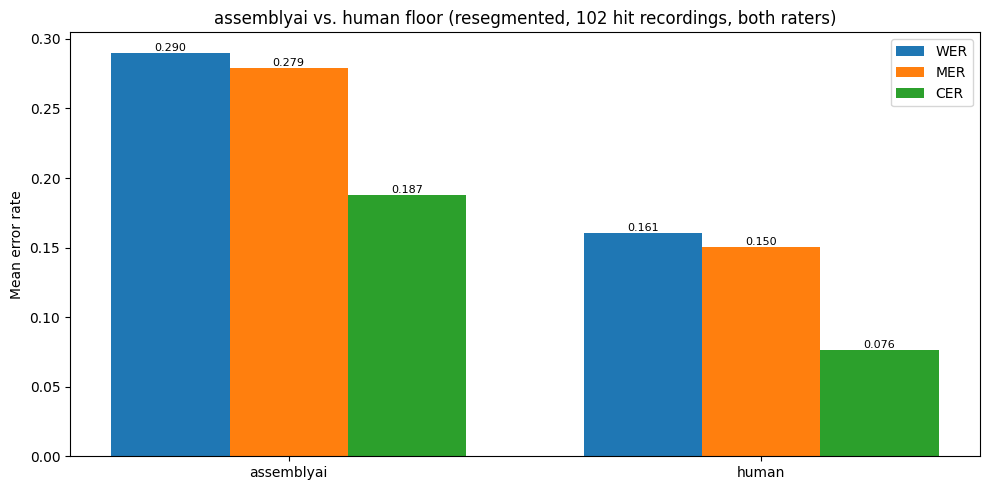

In [9]:
for source in ASR_SOURCES:
    pair = scores_with_human[scores_with_human["source"].isin([source, "human"])]
    plot_metrics(
        pair,
        f"{source} vs. human floor (resegmented, 102 hit recordings, both raters)",
        f"../plots/{source}_vs_human_metrics.png",
        order=[source, "human"],
    )
